Plot Figure 3a
--

In [1]:
cd ~/Pythons/

/home/users/guicha/Pythons


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from config import IUMFIGDIR
from IUM.read_data.read_data import load_raw_ctrl_surf_var, load_raw_pert_surf_var

In [4]:
res = 0.5
value = 0.3
value_pert = 1.
lengths = [25, 30, 35, 50, 75, 100, 125, 150]
u = 4.
env = 'stable'
date = '10010101'
time = 15
window = 3
rcrit = 10.

In [6]:
xs = np.arange(res, 400.+res, res)
ys = xs

xsm, ysm = np.meshgrid(xs, ys)

data_udry = load_raw_ctrl_surf_var(res=res, value=value, u=u, env=env, date=date, variable='PBLh')
data_udry = data_udry.rolling(T1HR_MN=window, center=True).mean()
data_udry_spacemean = data_udry.mean(dim=['latitude_t', 'longitude_t'])

data_uwet = load_raw_ctrl_surf_var(res=res, value=value_pert, u=u, env=env, date=date, variable='PBLh')
data_uwet = data_uwet.rolling(T1HR_MN=window, center=True).mean()
data_uwet_spacemean = data_uwet.mean(dim=['latitude_t', 'longitude_t'])


>>> 25 <<<
1381.4313099041533 248.439241657792

>>> 30 <<<
1219.9844537258023 189.7497016706444

>>> 35 <<<
1128.9309771033015 159.4798655484558

>>> 50 <<<
1057.1572858658183 158.14731945549366

>>> 75 <<<
1049.8638178913739 160.69334620163295

>>> 100 <<<
1125.3009148766903 183.94294174843102

>>> 125 <<<
1216.0684904153354 231.0256367589635

>>> 150 <<<
1308.8614757358791 269.5271700698312


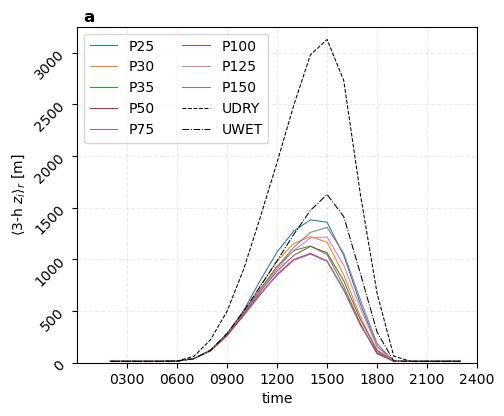

In [7]:
ts = np.arange(len(data_udry_spacemean)) + 1
ts2 = ts[11:19]
xtcks = np.arange(3, 24+3, 3)
xtlbs = [str(xt).zfill(2) + '00' for xt in xtcks]
ytcks = np.arange(0, 3000+500, 500)
ytlbs = ytcks

fig, ax = plt.subplots()

plt.subplots_adjust(left=0.15, top=0.95, right=0.95)

for length in lengths:
    print('\n>>> %i <<<'%length)

    data_pert = load_raw_pert_surf_var(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, variable='PBLh')
    data_pert = data_pert.rolling(T1HR_MN=window, center=True).mean()

    r = length / 2

    xc = (xs[-1] - xs[0]) / 2 + res / 2 + r / 2   # Sample centre-edge mid-point
    yc = (ys[-1] - ys[0]) / 2 + res / 2

    distloc = ( ((xsm - xc) * (xsm - xc)) + ((ysm - yc) * (ysm - yc)) )**.5  # 2d-array of distance to center values
    # sample area with constant radius
    disc_mask = np.broadcast_to(distloc <= rcrit, data_pert.shape)   # True in disc

    data_pert_wet = data_pert.where(disc_mask)
    data_pert_wet_spacemean = data_pert_wet.mean(dim=['latitude_t', 'longitude_t'])

    idxmin = np.nanargmin(data_pert_wet_spacemean.values)
    print(data_pert_wet_spacemean.max().values, data_pert_wet_spacemean.isel(T1HR_MN=slice(16,19)).mean().values)

    ax.plot(ts, data_pert_wet_spacemean.values, lw=0.75, label='P%i'%length)

ax.plot(ts, data_udry_spacemean.values, color='k', lw=0.75, ls='--', label='UDRY')
ax.plot(ts, data_uwet_spacemean.values, color='k', lw=0.75, ls='-.', label='UWET')

ax.text(0.015, 1.015, 'a', weight='bold', fontsize=12, transform=ax.transAxes)

ax.set_xlim(0, 24)
ax.set_xticks(xtcks)
ax.set_xticklabels(xtlbs)
ax.set_xlabel('time')
ax.set_ylim(0., 3250)
ax.set_yticks(ytcks)
ax.set_yticklabels(ytlbs, rotation=45)
ax.set_ylabel('$\\langle$%i-h $z_i \\rangle_{r}$ [m]'%window)
ax.grid(True, ls='--', alpha=0.25)
ax.legend(ncol=2, loc='upper left')

fig.set_size_inches(5., 4.)